In [2]:
import torch
import torchvision.datasets as dset
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np



In [ ]:
#load the train data from the data dir and convert it to tensor
raw_dataset = dset.CIFAR10(root="./data", train=True, download=True,transform=transforms.ToTensor())


CLASSES = ["airplane", "automobile", "bird", "cat", "deer","dog", "frog", "horse", "ship", "truck"]

/home/pranav/ml-env/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


### to check the class distribution 

In [ ]:
def plot_class_distribution(dataset):

    #dataset.targets directly returns a list of labels for each datapoint
    targets = dataset.targets

    #np.bincount returns a list of the number of times that index has occured
    #ie a list telling how many times the index (here 0 to 255) has occured
    counts = np.bincount(targets)

    plt.figure(figsize=(8, 4))
    plt.bar(CLASSES, counts)
    plt.xticks(rotation=45) #used to tilt the labels 
    plt.ylabel("count")
    plt.title("CIFAR-10 train set class distribution")
    plt.tight_layout()
    plt.savefig("class_distribution.png")
    plt.show()
    print(dict(zip(CLASSES, counts)))

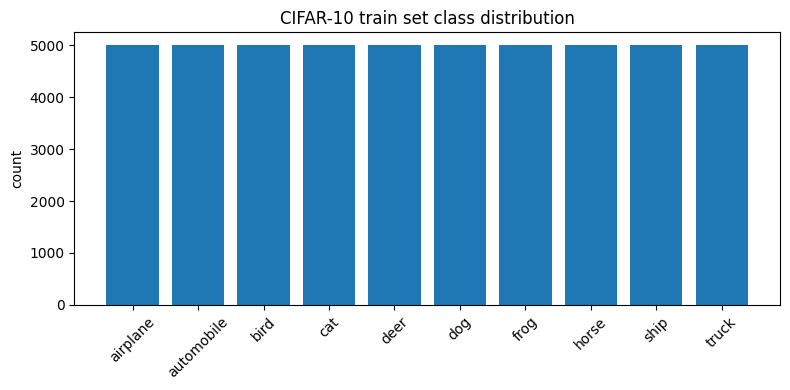

{'airplane': np.int64(5000), 'automobile': np.int64(5000), 'bird': np.int64(5000), 'cat': np.int64(5000), 'deer': np.int64(5000), 'dog': np.int64(5000), 'frog': np.int64(5000), 'horse': np.int64(5000), 'ship': np.int64(5000), 'truck': np.int64(5000)}


In [ ]:
plot_class_distribution(raw_dataset)
#so there are 5000 images of each class in the train dataset

### to see some images of each class 

In [6]:
def plot_sample_grid(dataset, n_per_class=4):
    targets = np.array(dataset.targets)
    fig, axes = plt.subplots(10, n_per_class, figsize=(n_per_class * 1.5, 10 * 1.5))
    for class_idx in range(10):
        class_indices = np.where(targets == class_idx)[0][:n_per_class]
        for col, idx in enumerate(class_indices):
            img, _ = dataset[idx]
            axes[class_idx, col].imshow(img.permute(1, 2, 0).numpy())
            axes[class_idx, col].axis("off")
            if col == 0:
                axes[class_idx, col].set_ylabel(CLASSES[class_idx])
    plt.tight_layout()
    plt.savefig("sample_grid.png")
    plt.show()

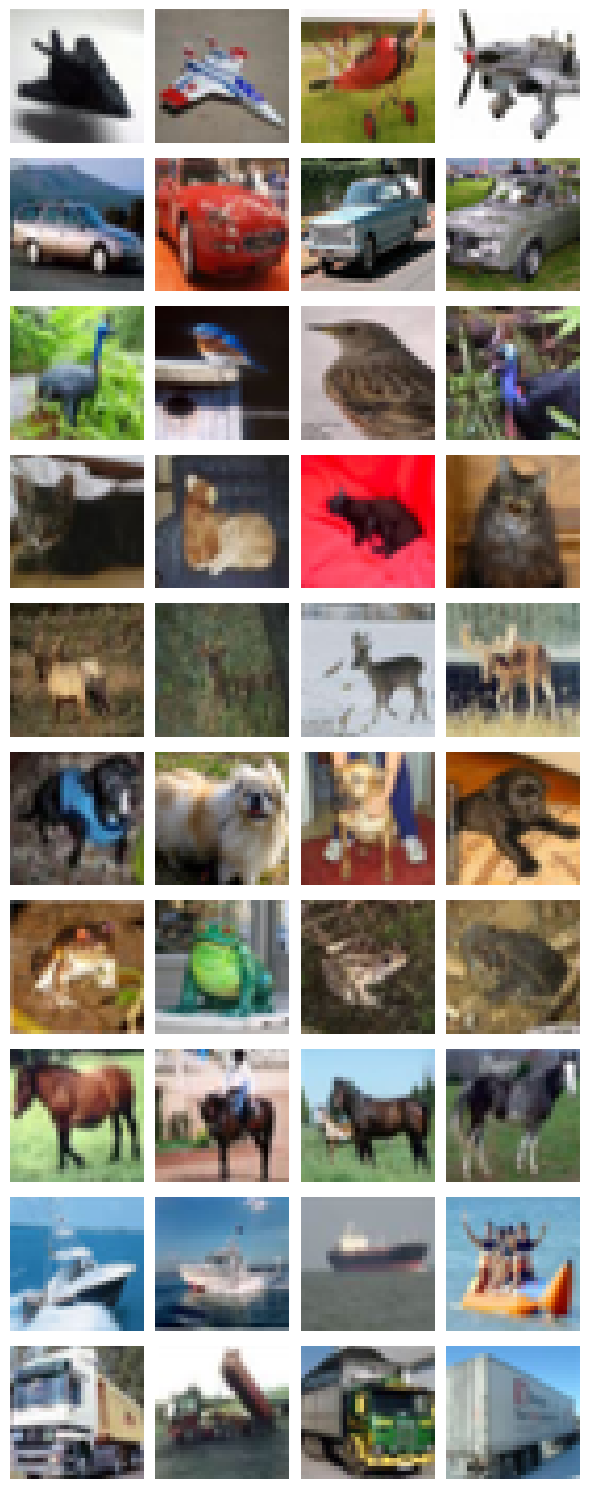

In [7]:
plot_sample_grid(raw_dataset)

### to see some images of a single class 

In [9]:
def plot_intraclass_variation(dataset, class_idx, n=8):
    targets = np.array(dataset.targets)
    class_indices = np.where(targets == class_idx)[0][:n]
    fig, axes = plt.subplots(1, n, figsize=(n * 1.5, 1.5))
    for col, idx in enumerate(class_indices):
        img, _ = dataset[idx]
        axes[col].imshow(img.permute(1, 2, 0).numpy())
        axes[col].axis("off")
    fig.suptitle(f"Intra-class variation: {CLASSES[class_idx]}")
    plt.tight_layout()
    plt.savefig(f"intraclass_{CLASSES[class_idx]}.png")
    plt.show()

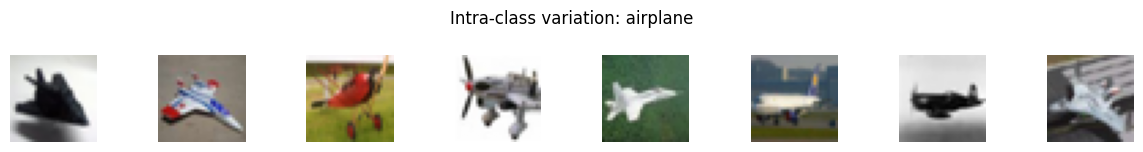

In [ ]:
plot_intraclass_variation(raw_dataset,0) #see some variations in plane class